# 89 - Denoising with an Autoencoder

**Section:** Autoencoders | **Prereqs:** `CNNs/DoAutoEncoders_CleanGaussians_(CNN_AE).ipynb` | **Next:** `Autoencoders/AE_for_Occlusion.ipynb`

A fully connected autoencoder on MNIST: 784 -> 250 -> **50** -> 250 -> 784. Train
it on clean digits only, then feed it noisy ones.

**The result:** the noise largely disappears, even though the model was never
shown a noisy image.

**Why it works.** The 50-unit bottleneck cannot represent arbitrary pixel
patterns - only about 6% of the input dimensionality survives. What it *can*
represent is the structure common to all digits, because that is what minimising
reconstruction error across 60000 images rewards. Random noise is different in
every image, so there is nothing to gain from encoding it, and the reconstruction
comes back clean.

**Compression as denoising.** Any lossy compression discards what is hardest to
predict, and noise is by definition unpredictable. That is the whole mechanism -
JPEG does something similar, on purpose.

**The limits.** Push the noise up and the reconstruction degrades; the bottleneck
only removes what it cannot encode. A *denoising autoencoder* proper is trained
on (noisy, clean) pairs - the supervised version in
`CNNs/CodeChallenge_Cleaning_Occulsions_with_AEs.ipynb` - and handles far more
noise.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

In [ ]:
data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


In [ ]:
# MNIST flattened to 784-vectors and scaled to [0,1] with MinMaxScaler.
# The [0,1] range matters: the decoder ends in sigmoid, whose range is exactly
# [0,1]. Match the output activation to the target's range.
def makeDataset():

  data_tensor = data.data.view(-1, 784)
  labels_tensor = data.targets


  from sklearn.preprocessing import MinMaxScaler

  scaler = MinMaxScaler()

  data_subset = scaler.fit_transform(data_tensor)

  train_data = torch.tensor(data_subset, dtype=torch.float, device='cuda')
  train_label = torch.tensor(labels_tensor, dtype=torch.long, device='cuda')


  return train_data, train_label

In [ ]:
train_data, train_label = makeDataset()

/tmp/ipython-input-289672233.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_label = torch.tensor(labels_tensor, dtype=torch.long, device='cuda')


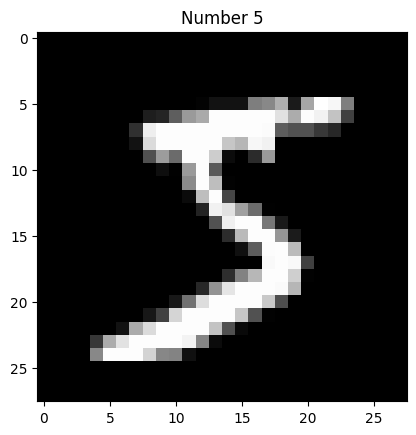

In [ ]:
# One clean training digit.
plt.imshow(train_data[0].reshape(28,28).detach().cpu(),cmap='gray');
plt.title(f'Number {str(train_label[0].item())}');

In [ ]:
# The autoencoder: 784 -> 250 -> 50 -> 250 -> 784, symmetric around the
# 50-unit bottleneck.
# Sigmoid on the output matches the [0,1] input range.
# The 50-dimensional code is the compression: 784 numbers down to 50, a 15x
# reduction, and everything the model knows about an image has to fit there.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784, 250)

    self.fc1 = nn.Linear(250,50)

    self.fc2 = nn.Linear(50,250)

    self.output_layer = nn.Linear(250,784)


  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.fc1(x))

    x = F.relu(self.fc2(x))

    return  F.sigmoid(self.output_layer(x))

In [ ]:
# An untrained forward pass, for comparison.
AutoEncoder = model().to('cuda')

output = AutoEncoder(train_data)

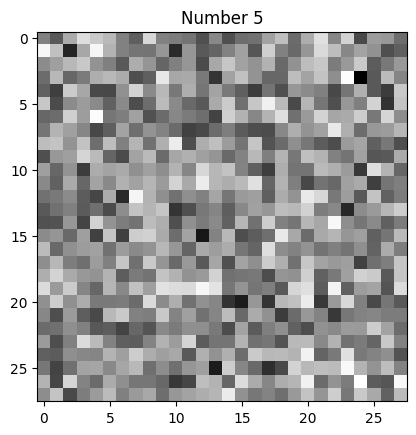

In [ ]:
# Random-weight output - noise. Everything below is what training adds.
plt.imshow(output[0].reshape(28,28).detach().cpu(),cmap='gray');
plt.title(f'Number {str(train_label[0].item())}');

### Now we train the AutoEncoder

In [ ]:
# Training: MSELoss(yhat, X) - target IS the input, so no labels are used.
# Batches are drawn by random sampling with replacement rather than by a
# DataLoader; 10000 iterations of batch 32 is roughly 5 epochs over MNIST.
def train_model():

  AutoEncoder = model().to('cuda')

  epochs = 10000
  lr = 0.001

  lossFunc =  nn.MSELoss()
  optimizer = torch.optim.Adam(AutoEncoder.parameters(), lr=lr)

  train_acc = []
  losses = []


  for i in range(epochs):

    AutoEncoder.train()

    randomidx = np.random.choice(train_data.shape[0],size=32) # Creating random batches
    X = train_data[randomidx,:]

    yhat = AutoEncoder(X)
    loss = lossFunc(yhat,X) # We compare the loss with the inital input
    losses.append(loss.item())


    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    if i % 1000 == 0 or i == epochs-1:
      print(f"Epoch {i} : Loss = {losses[i]}")

  print()
  return losses, AutoEncoder

In [ ]:
losses , AutoEncoder = train_model()

Epoch 0 : Loss = 0.23073454201221466
Epoch 1000 : Loss = 0.01745491661131382
Epoch 2000 : Loss = 0.013205990195274353
Epoch 3000 : Loss = 0.008994095958769321
Epoch 4000 : Loss = 0.009142307564616203
Epoch 5000 : Loss = 0.006788317114114761
Epoch 6000 : Loss = 0.006677567958831787
Epoch 7000 : Loss = 0.007606294471770525
Epoch 8000 : Loss = 0.006066887639462948
Epoch 9000 : Loss = 0.007900289259850979
Epoch 9999 : Loss = 0.005913754925131798



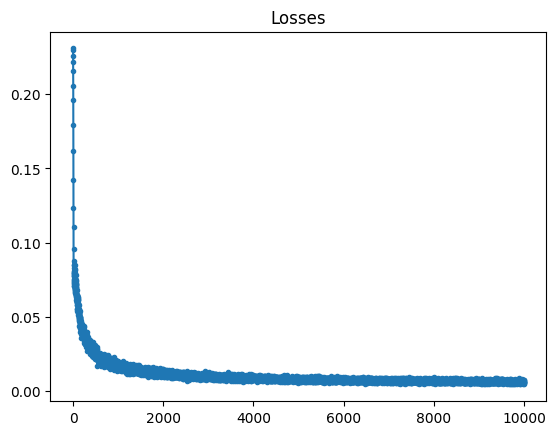

In [ ]:
# Reconstruction loss. Much noisier than a DataLoader-based curve because each
# point is a single batch rather than an epoch average.
plt.plot(losses, '.-')
plt.title("Losses");

Now we are testing the model:



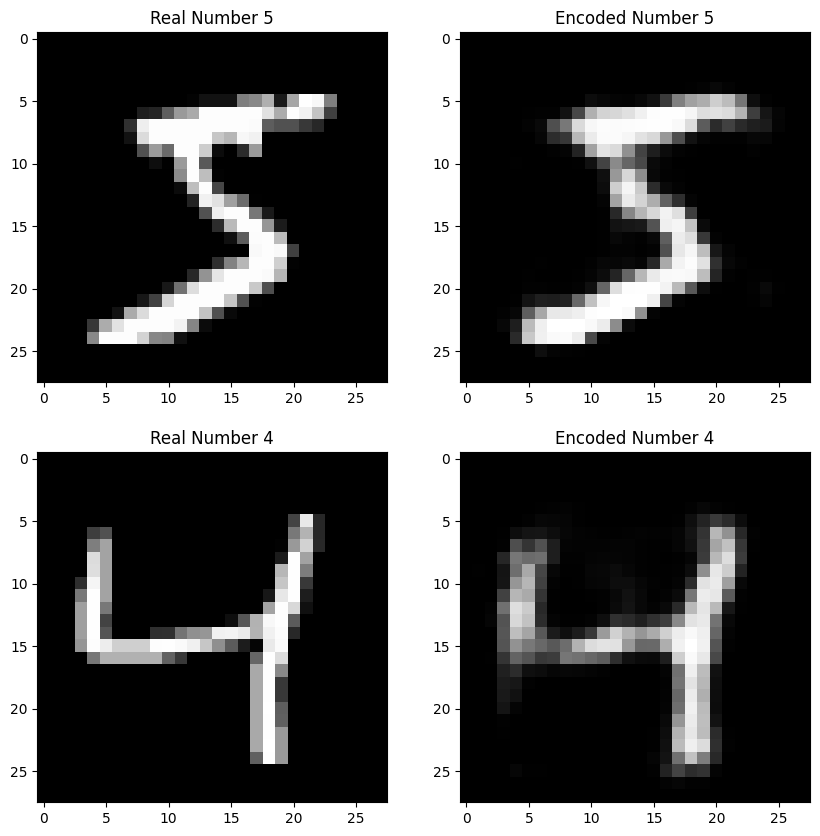

In [ ]:
print('Now we are testing the model:')
print()

encoded_outputs = AutoEncoder(train_data)

fig, ax = plt.subplots(2,2,figsize=(10,10))

ax[0, 0].imshow(train_data[0].reshape(28,28).detach().cpu(),cmap='gray');
ax[0, 0].set_title(f'Real Number {str(train_label[0].item())}');

ax[0, 1].imshow(encoded_outputs[0].reshape(28,28).detach().cpu(),cmap='gray');
ax[0, 1].set_title(f'Encoded Number {str(train_label[0].item())}');

ax[1, 0].imshow(train_data[2].reshape(28,28).detach().cpu(),cmap='gray');
ax[1, 0].set_title(f'Real Number {str(train_label[2].item())}');

ax[1, 1].imshow(encoded_outputs[2].reshape(28,28).detach().cpu(),cmap='gray');
ax[1, 1].set_title(f'Encoded Number {str(train_label[2].item())}');

# Adding Noise to test the autoenoder

In [ ]:
# THE TEST: add uniform noise to 10 clean digits and clip back into range.
# The model has never seen a noisy image.
subset = train_data[:10,:]

noisy_set = subset + torch.rand_like(subset) / 4

noisy_set[noisy_set>1] = 1


Now testing the noisy set: 



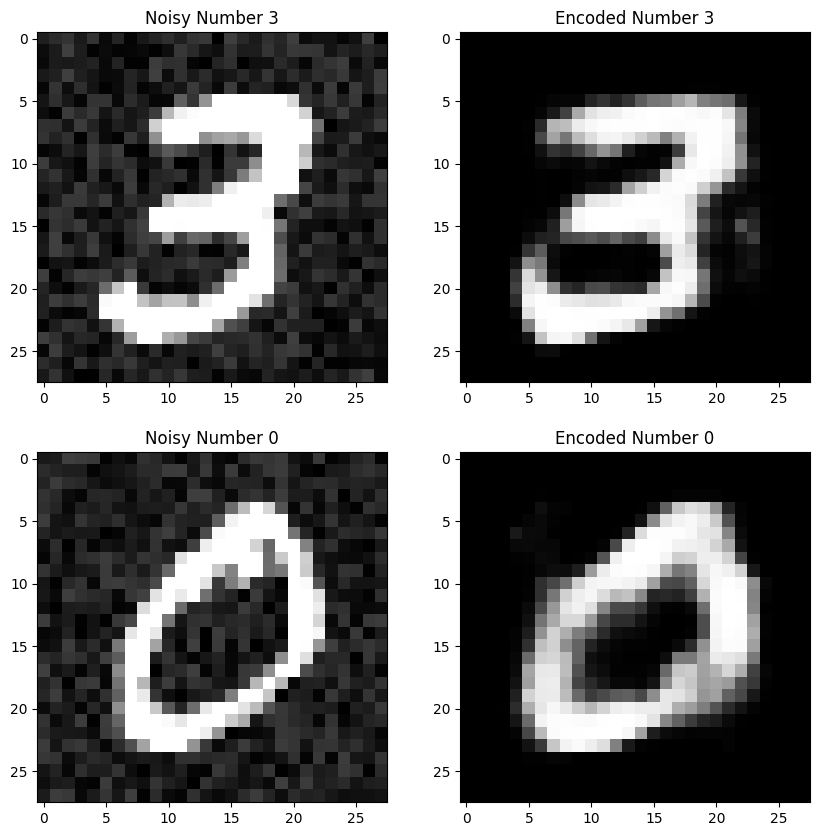

In [ ]:
# Noisy input (left) vs reconstruction (right).
# The noise is largely gone. The bottleneck could not encode it - noise differs
# in every image, so there is nothing to gain from representing it - while the
# digit structure, common to all 60000 training images, survives.
# Compression IS denoising when the discarded part is the unpredictable part.
print("Now testing the noisy set: ")
print()

noisy_ouput = AutoEncoder(noisy_set)

fig, ax = plt.subplots(2,2,figsize=(10,10))

ax[0, 0].imshow(noisy_set[7].reshape(28,28).detach().cpu(),cmap='gray');
ax[0, 0].set_title(f'Noisy Number {str(train_label[7].item())}');

ax[0, 1].imshow(noisy_ouput[7].reshape(28,28).detach().cpu(),cmap='gray');
ax[0, 1].set_title(f'Encoded Number {str(train_label[7].item())}');

ax[1, 0].imshow(noisy_set[1].reshape(28,28).detach().cpu(),cmap='gray');
ax[1, 0].set_title(f'Noisy Number {str(train_label[1].item())}');

ax[1, 1].imshow(noisy_ouput[1].reshape(28,28).detach().cpu(),cmap='gray');
ax[1, 1].set_title(f'Encoded Number {str(train_label[1].item())}');

### Conclusion

This notebook demonstrates the implementation and application of a basic Autoencoder neural network using PyTorch. We covered the following key concepts:

1.  **Data Loading and Preprocessing**: We loaded the MNIST dataset, normalized the pixel values, and converted them into tensors suitable for GPU processing.
2.  **Autoencoder Architecture**: We defined a simple Autoencoder model with an input layer, hidden layers, and an output layer, using ReLU activation for hidden layers and Sigmoid for the output layer to reconstruct the input.
3.  **Training Process**: The Autoencoder was trained using Mean Squared Error (MSE) loss, aiming to minimize the difference between the input images and their reconstructions. Adam optimizer was used for efficient training over 10,000 epochs.
4.  **Reconstruction**: After training, the model successfully reconstructed original MNIST digits, showing its ability to learn a compressed representation of the input data.
5.  **Denoising Application**: Finally, we tested the Autoencoder's robustness by adding random noise to a subset of the data. The model demonstrated its capability to effectively denoise the images, producing cleaner reconstructions from noisy inputs.

This notebook serves as a foundational example of how autoencoders can be used for tasks like dimensionality reduction, feature learning, and data denoising.